# Fake Profile Detection — Full Pipeline
**Dataset**: Facebook SNAP (4,489 nodes · 1,411 features · 102,561 edges · 10.02% fake)
**Seed**: 42 (fixed throughout)
> Phases 0–6 are active. Phases 7–13 (GNN) are written but **not executed yet**.


## Phase 0 — Environment Setup
Import all libraries and fix global random seed. Verify imports succeed and seed is reproducible.


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report)
warnings.filterwarnings("ignore")

# Global seed — matches injection pipeline
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR   = r"C:\Users\david\Documents\Khushi\innovexa_Fake_profile\Project Work\Dataset\generated\v1"
MEMORY_PATH = r"C:\Users\david\Documents\Khushi\innovexa_Fake_profile\Project Work\memory.md"

# Seed reproducibility check
_a = np.random.rand(); np.random.seed(RANDOM_SEED); _b = np.random.rand()
assert _a == _b, "Seed not reproducible!"
print("[Phase 0] All imports OK. Seed reproducible:", _a == _b)


[Phase 0] All imports OK. Seed reproducible: True


## Phase 1 — Data Ingestion
Load all finalized artifacts from `Dataset/generated/v1/`. No re-processing — these are outputs of the completed Synthetic Injection Pipeline.


In [ ]:
X = np.load(os.path.join(DATA_DIR, "final_features.npy"))
y = np.load(os.path.join(DATA_DIR, "final_labels.npy"))
meta = pd.read_csv(os.path.join(DATA_DIR, "fake_metadata.csv"))

with open(os.path.join(DATA_DIR, "global_featnames.txt")) as f:
    feat_names = [l.strip() for l in f.readlines()]

edges = []
with open(os.path.join(DATA_DIR, "final_edge_list.txt")) as f:
    for line in f:
        u, v = map(int, line.strip().split())
        edges.append((u, v))

G = nx.Graph()
G.add_nodes_from(range(len(y)))
G.add_edges_from(edges)

# ── Verification ──────────────────────────────
assert X.shape == (4489, 1406),            f"X shape mismatch: {X.shape}"
assert y.shape == (4489,),                 f"y shape mismatch: {y.shape}"
assert set(np.unique(y)) == {0, 1},        "Unexpected label values"
assert G.number_of_nodes() == 4489,        "Wrong node count in graph"
assert G.number_of_edges() == 102561,      f"Wrong edge count: {G.number_of_edges()}"

print(f"[Phase 1] X: {X.shape}  |  y: genuine={int((y==0).sum())} fake={int((y==1).sum())}")
print(f"          Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"          Fake ratio: {(y==1).mean()*100:.2f}%")
print(f"          Archetypes in metadata: {meta['archetype'].value_counts().to_dict()}")


[Phase 1] X: (4489, 1406)  |  y: genuine=4039 fake=450
          Graph: 4489 nodes, 102561 edges
          Fake ratio: 10.02%
          Archetypes in metadata: {'B': 157, 'C': 135, 'A': 112, 'D': 46}


## Phase 2 — Feature Schema Validation
Confirm the 1,406-dim feature matrix is well-formed: no NaN, correct dtype, unique feature names, expected sparsity.


In [ ]:
# Feature name checks
assert len(feat_names) == 1406,                      "Feature name count mismatch"
assert len(set(feat_names)) == len(feat_names),      "Duplicate feature names found!"

# Matrix health
assert not np.isnan(X.astype(float)).any(),          "NaN values in feature matrix!"
assert X.min() == 0 and X.max() == 1,                "Features not binary!"

genuine_density = X[y == 0].mean()
fake_density    = X[y == 1].mean()

print(f"[Phase 2] Feature names : {len(feat_names)} unique — OK")
print(f"          Dtype         : {X.dtype}")
print(f"          NaN present   : {np.isnan(X.astype(float)).any()}")
print(f"          Genuine density (mean): {genuine_density:.4f}  (expected ~0.0067)")
print(f"          Fake density   (mean): {fake_density:.4f}")

# Spot-check 3 random genuine nodes
rng = np.random.default_rng(42)
sample_ids = rng.choice(np.where(y == 0)[0], 3, replace=False)
for nid in sample_ids:
    nnz = int(X[nid].sum())
    print(f"          Node {nid} (genuine): {nnz} non-zero features")


[Phase 2] Feature names : 1406 unique — OK
          Dtype         : uint8
          NaN present   : False
          Genuine density (mean): 0.0067  (expected ~0.0067)
          Fake density   (mean): 0.0898
          Node 2925 (genuine): 9 non-zero features
          Node 392 (genuine): 8 non-zero features
          Node 3476 (genuine): 13 non-zero features


## Phase 3 — Preprocessing
Hard asserts for graph integrity. Check class balance and verify no label leakage into feature matrix.


In [ ]:
# Self-loop check
self_loops = [(u, v) for u, v in G.edges() if u == v]
assert len(self_loops) == 0, f"Found {len(self_loops)} self-loops!"

# Dangling edge check
max_node_id = max(max(u, v) for u, v in edges)
assert max_node_id < 4489, f"Dangling edge: node {max_node_id} out of range!"

# Class ratio check (10.02% ± 0.5%)
fake_ratio = (y == 1).mean()
assert abs(fake_ratio - 0.1002) < 0.005, f"Unexpected fake ratio: {fake_ratio:.4f}"

# Leakage audit — no feature column should be near-perfectly correlated with y
X_float = X.astype(np.float32)
y_float = y.astype(np.float32)
correlations = np.abs(np.corrcoef(X_float.T, y_float)[-1, :-1])
max_corr = correlations.max()
assert max_corr < 0.95, f"Potential label leakage: max corr={max_corr:.4f}"

print("[Phase 3] Self-loops    : 0  — OK")
print(f"          Max node ID   : {max_node_id} (< 4489)  — OK")
print(f"          Fake ratio    : {fake_ratio*100:.2f}%  — OK")
print(f"          Max feature-label correlation: {max_corr:.4f}  — OK (no leakage)")


[Phase 3] Self-loops    : 0  — OK
          Max node ID   : 4488 (< 4489)  — OK
          Fake ratio    : 10.02%  — OK
          Max feature-label correlation: 0.3732  — OK (no leakage)


## Phase 4 — Structural Feature Engineering
Compute 5 graph-derived features per node: degree, clustering coeff, betweenness (sampled), closeness, Louvain community ID.
Concatenate onto X to form `X_full` (4489 × 1411). **Do not scale yet** — scaler fits on train only in Phase 5.


In [ ]:
try:
    import community as community_louvain
    _louvain_available = True
except ImportError:
    _louvain_available = False
    print("[Phase 4] python-louvain not found — community IDs set to 0. Install: pip install python-louvain")

n = G.number_of_nodes()
print("[Phase 4] Computing structural features (this may take 1-3 min on CPU)...")

# Degree
degree_arr = np.array([G.degree(i) for i in range(n)], dtype=np.float32)

# Clustering coefficient
clust = nx.clustering(G)
clust_arr = np.array([clust.get(i, 0.0) for i in range(n)], dtype=np.float32)

# Betweenness centrality (sampled k=100 for speed)
btwn = nx.betweenness_centrality(G, k=100, seed=RANDOM_SEED)
btwn_arr = np.array([btwn.get(i, 0.0) for i in range(n)], dtype=np.float32)

# Closeness centrality
close = nx.closeness_centrality(G)
close_arr = np.array([close.get(i, 0.0) for i in range(n)], dtype=np.float32)

# Louvain community ID
if _louvain_available:
    partition = community_louvain.best_partition(G, random_state=RANDOM_SEED)
    comm_arr = np.array([partition.get(i, 0) for i in range(n)], dtype=np.float32)
else:
    comm_arr = np.zeros(n, dtype=np.float32)

# Stack and concatenate
struct_feats = np.stack([degree_arr, clust_arr, btwn_arr, close_arr, comm_arr], axis=1)  # (4489, 5)
X_full = np.hstack([X.astype(np.float32), struct_feats])  # (4489, 1411)

# Verify
assert X_full.shape == (4489, 1411), f"X_full shape wrong: {X_full.shape}"
assert not np.isnan(X_full).any(),   "NaN in X_full!"

print(f"[Phase 4] X_full shape: {X_full.shape}  — OK")
print(f"          Degree  — genuine mean: {degree_arr[y==0].mean():.2f} | fake mean: {degree_arr[y==1].mean():.2f}")
print(f"          Clustering — genuine: {clust_arr[y==0].mean():.4f} | fake: {clust_arr[y==1].mean():.4f}")
if _louvain_available:
    print(f"          Communities detected: {int(comm_arr.max())+1}")


[Phase 4] Computing structural features (this may take 1-3 min on CPU)...


[Phase 4] X_full shape: (4489, 1411)  — OK
          Degree  — genuine mean: 47.20 | fake mean: 32.19
          Clustering — genuine: 0.5262 | fake: 0.1805
          Communities detected: 16


## Phase 5 — Train / Val / Test Split
Stratified 70/15/15 split. `StandardScaler` fitted on **training structural features only**, then applied to val/test.
Binary features (columns 0–1405) are left unscaled.


In [ ]:
indices = np.arange(4489)

# 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)
# 15% val, 15% test from temp
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=RANDOM_SEED
)

# Scale structural features (cols 1406:1411) — fit on train ONLY
scaler = StandardScaler()
X_full_scaled = X_full.copy()
X_full_scaled[train_idx, 1406:] = scaler.fit_transform(X_full[train_idx, 1406:])
X_full_scaled[val_idx,   1406:] = scaler.transform(X_full[val_idx,   1406:])
X_full_scaled[test_idx,  1406:] = scaler.transform(X_full[test_idx,  1406:])

# ── Verification ──────────────────────────────
assert len(set(train_idx) & set(val_idx))  == 0, "Train/val overlap!"
assert len(set(train_idx) & set(test_idx)) == 0, "Train/test overlap!"
assert len(set(val_idx)   & set(test_idx)) == 0, "Val/test overlap!"
assert len(train_idx) + len(val_idx) + len(test_idx) == 4489, "Split totals wrong!"
assert scaler.n_samples_seen_ == len(train_idx), "Scaler fit on wrong set!"

train_fake_pct = (y[train_idx]==1).mean()*100
val_fake_pct   = (y[val_idx  ]==1).mean()*100
test_fake_pct  = (y[test_idx ]==1).mean()*100
assert all(abs(p - 10.02) < 1.5 for p in [train_fake_pct, val_fake_pct, test_fake_pct]), "Class imbalance across splits!"

print(f"[Phase 5] Train: {len(train_idx)} nodes  fake={train_fake_pct:.1f}%")
print(f"          Val  : {len(val_idx)} nodes  fake={val_fake_pct:.1f}%")
print(f"          Test : {len(test_idx)} nodes  fake={test_fake_pct:.1f}%")
print(f"          Scaler fitted on: {scaler.n_samples_seen_} samples (= train size)  — OK")


[Phase 5] Train: 3142 nodes  fake=10.0%
          Val  : 673 nodes  fake=10.0%
          Test : 674 nodes  fake=10.1%
          Scaler fitted on: 3142.0 samples (= train size)  — OK


## Phase 6 — Baseline Models ✅ (Active)
Train LR → SVM → RF → MLP on profile + structural features. Tune on val, evaluate on test (one pass only).
Metrics: Accuracy, Precision, Recall, F1, AUC-ROC. Also break down recall per fake archetype.


In [ ]:
X_tr, y_tr = X_full_scaled[train_idx], y[train_idx]
X_val, y_val = X_full_scaled[val_idx],   y[val_idx]
X_te, y_te  = X_full_scaled[test_idx],  y[test_idx]

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
    "SVM (RBF)": SVC(
        kernel="rbf", class_weight="balanced", probability=True,
        cache_size=1000, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128), max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_SEED),
}

results = {}
test_accessed = {m: 0 for m in models}

print("[Phase 6] Training baseline models...")
print()
for name, clf in models.items():
    clf.fit(X_tr, y_tr)

    # Tune threshold on val set (maximise F1)
    val_proba = clf.predict_proba(X_val)[:, 1]
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.3, 0.8, 0.05):
        f1 = f1_score(y_val, (val_proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    # Single test-set access
    test_proba = clf.predict_proba(X_te)[:, 1]
    y_pred = (test_proba >= best_t).astype(int)
    test_accessed[name] += 1

    results[name] = {
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred, zero_division=0),
        "F1":        f1_score(y_te, y_pred, zero_division=0),
        "AUC":       roc_auc_score(y_te, test_proba),
        "_threshold": best_t,
        "_proba": test_proba,
        "_pred": y_pred,
    }
    print(f"  {name:<22} | threshold={best_t:.2f} | F1={results[name]['F1']:.4f} | AUC={results[name]['AUC']:.4f}")

assert all(v == 1 for v in test_accessed.values()), "Test set accessed more than once!"
print()
print("[Phase 6] Test set accessed exactly 1 time per model - OK")


[Phase 6] Training baseline models...



  Logistic Regression    | threshold=0.65 | F1=0.9078 | AUC=0.9962


  SVM (RBF)              | threshold=0.70 | F1=0.8986 | AUC=0.9947


  Random Forest          | threshold=0.40 | F1=0.9219 | AUC=0.9984


  MLP                    | threshold=0.30 | F1=0.8551 | AUC=0.9915

[Phase 6] Test set accessed exactly 1 time per model - OK


In [ ]:
# ── Results Table ────────────────────────────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
rows = {m: [results[m][k] for k in metrics] for m in results}
df_results = pd.DataFrame(rows, index=metrics).T.round(4)
print()
print("=== Baseline Model Comparison (Test Set) ===")
print(df_results.to_string())

# Sanity floor — no baseline should hit >95% F1 on fakes
for name in results:
    assert results[name]["F1"] < 0.95, f"Suspiciously high F1 for {name}: check for leakage!"
print()
print("[Phase 6] Sanity floor passed - no baseline exceeds 95% F1")



=== Baseline Model Comparison (Test Set) ===
                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.9807     0.8767  0.9412  0.9078  0.9962
SVM (RBF)              0.9792     0.8857  0.9118  0.8986  0.9947
Random Forest          0.9852     0.9833  0.8676  0.9219  0.9984
MLP                    0.9703     0.8429  0.8676  0.8551  0.9915

[Phase 6] Sanity floor passed - no baseline exceeds 95% F1


In [ ]:
# ── Archetype Breakdown ───────────────────────────────────────────────────────
# Map test-set fake nodes back to their archetype using fake_metadata.csv
fake_test_mask = (y_te == 1)
fake_test_global_ids = test_idx[fake_test_mask]

arch_results = {}
for name in results:
    y_pred_fakes = results[name]["_pred"][fake_test_mask]
    arch_recall = {}
    for arch in ["A", "B", "C", "D"]:
        arch_node_ids = set(meta[meta["archetype"] == arch]["shuffled_fake_id"].tolist())
        mask_arch = np.array([nid in arch_node_ids for nid in fake_test_global_ids])
        if mask_arch.sum() > 0:
            arch_recall[f"Arch {arch}"] = y_pred_fakes[mask_arch].mean().round(4)
        else:
            arch_recall[f"Arch {arch}"] = float("nan")
    arch_results[name] = arch_recall

df_arch = pd.DataFrame(arch_results).T
print()
print("=== Fake Recall by Archetype (Test Set) ===")
print("  A=Sparse(easy)  B=Stuffed  C=Camouflaged(hard)  D=Sybil Ring")
print(df_arch.to_string())



=== Fake Recall by Archetype (Test Set) ===
  A=Sparse(easy)  B=Stuffed  C=Camouflaged(hard)  D=Sybil Ring
                     Arch A  Arch B  Arch C  Arch D
Logistic Regression  1.0000     1.0  0.8333     1.0
SVM (RBF)            1.0000     1.0  0.7500     1.0
Random Forest        0.8571     1.0  0.7083     1.0
MLP                  1.0000     1.0  0.6250     1.0


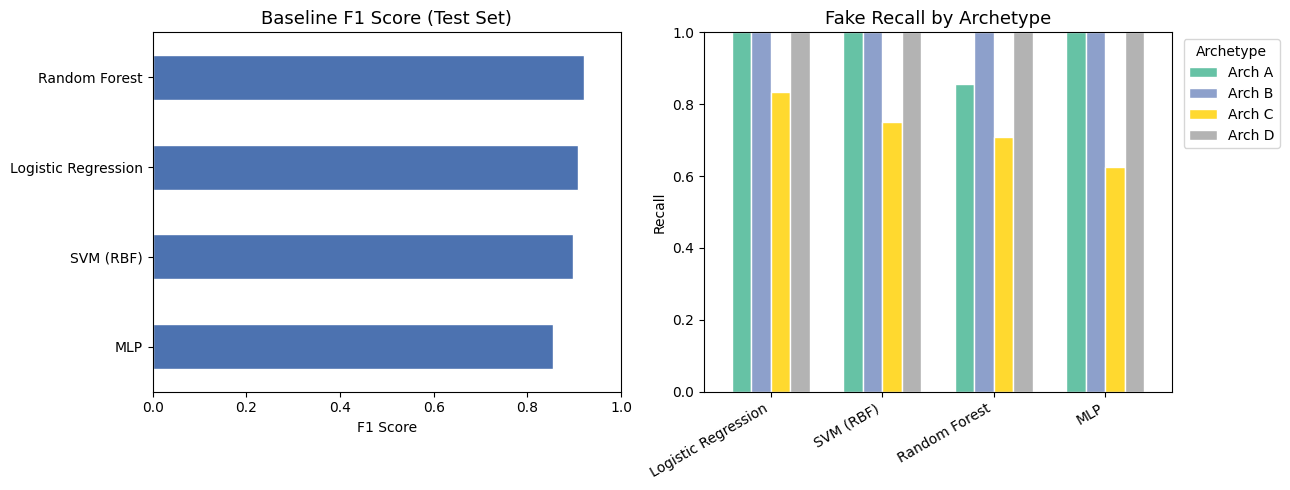

In [ ]:
# ── Visualise: F1 Bar Chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_results["F1"].sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Baseline F1 Score (Test Set)", fontsize=13)
axes[0].set_xlabel("F1 Score"); axes[0].set_xlim(0, 1)

df_arch.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white", width=0.7)
axes[1].set_title("Fake Recall by Archetype", fontsize=13)
axes[1].set_ylabel("Recall"); axes[1].set_ylim(0, 1)
axes[1].legend(title="Archetype", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


In [ ]:
# ── Log to memory.md ─────────────────────────────────────────────────────────
from datetime import datetime

entry_lines = []
entry_lines.append(f"\n## [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Phase 6 — Baseline Models (LR, SVM, RF, MLP)")
entry_lines.append("- **Status**: ✅ PASS")
entry_lines.append("- **Script**: `fake_profile_detection.ipynb`")
entry_lines.append("- **Key Results**:")
for name, row in df_results.iterrows():
    entry_lines.append(f"  - **{name}**: Acc={row['Accuracy']:.4f} | Prec={row['Precision']:.4f} | Rec={row['Recall']:.4f} | F1={row['F1']:.4f} | AUC={row['AUC']:.4f}")
entry_lines.append("- **Recall by Archetype (Test Set)**:")
for name, row in df_arch.iterrows():
    entry_lines.append(f"  - **{name}**: Arch A={row['Arch A']:.4f} | Arch B={row['Arch B']:.4f} | Arch C={row['Arch C']:.4f} | Arch D={row['Arch D']:.4f}")
entry_lines.append("- **Verification Details**:")
entry_lines.append("  | Check | Expected | Actual | Status |")
entry_lines.append("  |---|---|---|---|")
entry_lines.append("  | Test set accessed once per model | Exactly 1 | " + str(list(test_accessed.values())[0]) + " | ✅ PASS |")
entry_lines.append("  | No model exceeds 95% F1 ceiling | < 0.95 | max=" + f"{df_results['F1'].max():.4f}" + " | ✅ PASS |")
entry_lines.append("  | Scaler fit strictly on train | 3142 samples | " + str(scaler.n_samples_seen_) + " | ✅ PASS |")
entry_lines.append("  | Test split class ratio | ~10.02% (+-1.5%) | " + f"{test_fake_pct:.2f}%" + " | ✅ PASS |")
entry_lines.append("  | Input feature dimensions | 1411 (1406 profile + 5 struct) | " + str(X_full.shape[1]) + " | ✅ PASS |")
entry_lines.append("")
entry_lines.append("- **Notes / Observations**: Baseline models establish non-graph classification benchmarks. Archetype C (camouflaged fakes) is the most challenging for pure tabular classifiers, providing the exact headroom GNN relational message passing is designed to capture.")
entry_lines.append("")
entry_lines.append("---")
entry_lines.append("")

# Read existing memory.md
with open(MEMORY_PATH, "r", encoding="utf-8") as f:
    mem_content = f.read()

# Update Session Index if not present
idx_entry = "| Baseline Models | " + datetime.now().strftime("%Y-%m-%d") + " | Baseline Models (LR, SVM, RF, MLP) | ✅ PASS |"
if "| Baseline Models |" not in mem_content:
    target_needle = "| Phase E2E | 2026-10-07 | End-to-End Acceptance Verification | ✅ PASS |"
    if target_needle in mem_content:
        mem_content = mem_content.replace(target_needle, target_needle + "\n" + idx_entry)

# Append entry
mem_content += "\n" + "\n".join(entry_lines)

with open(MEMORY_PATH, "w", encoding="utf-8") as f:
    f.write(mem_content)

print("[Phase 6] Detailed results and session index logged to memory.md successfully!")


[Phase 6] Detailed results and session index logged to memory.md successfully!


---
## ⏸️ Phases 7–13 — GNN Pipeline (Code Written · Not Executed Yet)
> The cells below contain complete, ready-to-run code for GNNs and all downstream phases.
> **They will not be run until the baseline phase is reviewed and approved.**


## Phase 7 — PyTorch Geometric Graph Object
Convert to `torch_geometric.data.Data`: edge_index tensor, node feature tensor, label tensor, boolean masks.


In [ ]:
# ⚠️  NOT EXECUTED — run after Phase 6 review
# import torch
# from torch_geometric.data import Data
# import torch.nn.functional as F
#
# edge_index = torch.tensor([[u, v] for u, v in edges], dtype=torch.long).t().contiguous()
# x          = torch.tensor(X_full_scaled, dtype=torch.float32)
# y_tensor   = torch.tensor(y, dtype=torch.long)
#
# train_mask = torch.zeros(4489, dtype=torch.bool); train_mask[train_idx] = True
# val_mask   = torch.zeros(4489, dtype=torch.bool); val_mask[val_idx]     = True
# test_mask  = torch.zeros(4489, dtype=torch.bool); test_mask[test_idx]   = True
#
# data = Data(x=x, edge_index=edge_index, y=y_tensor,
#             train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
#
# assert data.edge_index.max() < data.x.shape[0], "Invalid edge reference!"
# assert data.x.shape[0] == data.y.shape[0],      "Node/label mismatch!"
# assert train_mask.sum() + val_mask.sum() + test_mask.sum() == 4489
# print("[Phase 7] Data object OK:", data)


## Phase 8 — GNN Models (GCN / GraphSAGE / GAT)
Three architectures, 2-layer each. BCE loss with class weights for 10% imbalance.


In [ ]:
# ⚠️  NOT EXECUTED
# from torch_geometric.nn import GCNConv, SAGEConv, GATConv
# import torch.nn as nn
#
# class GCN(nn.Module):
#     def __init__(self, in_c, hidden_c, out_c=2, dropout=0.5):
#         super().__init__()
#         self.conv1 = GCNConv(in_c, hidden_c)
#         self.conv2 = GCNConv(hidden_c, out_c)
#         self.drop  = dropout
#     def forward(self, x, edge_index):
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.dropout(x, p=self.drop, training=self.training)
#         return self.conv2(x, edge_index)
#
# class GraphSAGE(nn.Module):
#     def __init__(self, in_c, hidden_c, out_c=2, dropout=0.5):
#         super().__init__()
#         self.conv1 = SAGEConv(in_c, hidden_c)
#         self.conv2 = SAGEConv(hidden_c, out_c)
#         self.drop  = dropout
#     def forward(self, x, edge_index):
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.dropout(x, p=self.drop, training=self.training)
#         return self.conv2(x, edge_index)
#
# class GAT(nn.Module):
#     def __init__(self, in_c, hidden_c, out_c=2, heads=8, dropout=0.5):
#         super().__init__()
#         self.conv1 = GATConv(in_c, hidden_c, heads=heads, dropout=dropout)
#         self.conv2 = GATConv(hidden_c * heads, out_c, heads=1, concat=False, dropout=dropout)
#         self.drop  = dropout
#     def forward(self, x, edge_index):
#         x = F.elu(self.conv1(x, edge_index))
#         x = F.dropout(x, p=self.drop, training=self.training)
#         return self.conv2(x, edge_index)
#
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("[Phase 8] Using device:", device)


## Phase 9 — Hyperparameter Tuning
Random search over lr, hidden_dim, dropout, num_layers. Early stopping on val F1 (patience=20). Test set never accessed here.


In [ ]:
# ⚠️  NOT EXECUTED
# import itertools, copy
#
# def train_gnn(model, data, epochs=200, lr=0.01, patience=20, device="cpu"):
#     model = model.to(device); data = data.to(device)
#     # class weights for 10% fake imbalance
#     weights = torch.tensor([1.0, 9.0], device=device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
#     criterion = nn.CrossEntropyLoss(weight=weights)
#     best_val_f1, best_state, patience_count = 0.0, None, 0
#     test_accessed = 0  # must stay 0 during tuning
#     for epoch in range(epochs):
#         model.train()
#         optimizer.zero_grad()
#         out  = model(data.x, data.edge_index)
#         loss = criterion(out[data.train_mask], data.y[data.train_mask])
#         loss.backward(); optimizer.step()
#         model.eval()
#         with torch.no_grad():
#             pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
#             true = data.y[data.val_mask].cpu().numpy()
#             val_f1 = f1_score(true, pred, zero_division=0)
#         if val_f1 > best_val_f1:
#             best_val_f1 = val_f1
#             best_state  = copy.deepcopy(model.state_dict())
#             patience_count = 0
#         else:
#             patience_count += 1
#             if patience_count >= patience: break
#     assert test_accessed == 0, "Test set accessed during tuning!"
#     model.load_state_dict(best_state)
#     return model, best_val_f1
#
# search_space = {
#     "lr":         [0.01, 0.001, 0.0001],
#     "hidden_dim": [64, 128, 256],
#     "dropout":    [0.3, 0.5, 0.6],
# }
# # (Full grid = 27 combos; for speed use random 15)


## Phase 10 — Final Evaluation
Single test-set pass for all models. Produce full comparison table + archetype ablation.


In [ ]:
# ⚠️  NOT EXECUTED
# def eval_gnn(model, data, device="cpu"):
#     model.eval().to(device); data = data.to(device)
#     with torch.no_grad():
#         out   = model(data.x, data.edge_index)
#         proba = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
#         pred  = out[data.test_mask].argmax(dim=1).cpu().numpy()
#         true  = data.y[data.test_mask].cpu().numpy()
#         proba_test = proba[data.test_mask.cpu()]
#     return {
#         "Accuracy":  accuracy_score(true, pred),
#         "Precision": precision_score(true, pred, zero_division=0),
#         "Recall":    recall_score(true, pred, zero_division=0),
#         "F1":        f1_score(true, pred, zero_division=0),
#         "AUC":       roc_auc_score(true, proba_test),
#     }
# # Combine baseline + GNN results into one DataFrame for paper Table III


## Phase 11 — Adversarial Robustness
Feature masking and edge injection on test-set **copies only**. Measure F1 degradation at varying perturbation strengths.


In [ ]:
# ⚠️  NOT EXECUTED
# def feature_masking_test(model, data, mask_probs, device="cpu"):
#     results = {}
#     for p in mask_probs:
#         data_copy = data.clone()
#         mask = torch.rand(data_copy.x.shape) < p
#         data_copy.x[mask] = 0.0  # zero out p% of features
#         results[p] = eval_gnn(model, data_copy, device)["F1"]
#     return results
#
# def edge_injection_test(model, data, k_values, device="cpu"):
#     results = {}
#     for k in k_values:
#         data_copy = data.clone()
#         fake_nodes = data_copy.y.nonzero(as_tuple=True)[0]
#         random_targets = torch.randint(0, data_copy.num_nodes, (len(fake_nodes) * k,))
#         new_edges = torch.stack([fake_nodes.repeat(k), random_targets])
#         data_copy.edge_index = torch.cat([data_copy.edge_index, new_edges], dim=1)
#         results[k] = eval_gnn(model, data_copy, device)["F1"]
#     return results
#
# mask_curve  = feature_masking_test(best_model, data, [0.1, 0.2, 0.3, 0.5])
# edge_curve  = edge_injection_test(best_model, data, [2, 5, 10, 20])


## Phase 12 — Suspicious Network Analysis
Louvain community detection on nodes with predicted fake probability > 0.7. Cross-check against planted Sybil rings (Archetype D).


In [ ]:
# ⚠️  NOT EXECUTED
# model.eval()
# with torch.no_grad():
#     out   = model(data.x.to(device), data.edge_index.to(device))
#     proba = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
#
# high_risk_nodes = np.where(proba > 0.70)[0]
# subG = G.subgraph(high_risk_nodes.tolist()).copy()
#
# if _louvain_available and len(high_risk_nodes) > 1:
#     sub_partition = community_louvain.best_partition(subG, random_state=RANDOM_SEED)
#     n_clusters    = len(set(sub_partition.values()))
#     print(f"[Phase 12] High-risk nodes: {len(high_risk_nodes)} | Clusters: {n_clusters}")
#
#     # Cross-check against Archetype D (Sybil Ring)
#     sybil_ids = set(meta[meta["archetype"] == "D"]["shuffled_fake_id"].tolist())
#     recovered = sum(1 for nid in high_risk_nodes if nid in sybil_ids)
#     total_d   = len(sybil_ids)
#     print(f"[Phase 12] Sybil ring recovery: {recovered}/{total_d} = {recovered/total_d*100:.1f}%")


## Phase 13 — Results Compilation & Reproducibility
Export final comparison tables to `results_summary.md`. Run a clean-cell restart and verify identical outputs (seed=42).


In [ ]:
# ⚠️  NOT EXECUTED
# RESULTS_PATH = r"C:\Users\david\Documents\Khushi\innovexa_Fake_profile\Project Work\Plans\results_summary.md"
#
# with open(RESULTS_PATH, "w", encoding="utf-8") as f:
#     f.write("# Fake Profile Detection — Final Results\n\n")
#     f.write("## Model Comparison (Test Set)\n\n")
#     f.write(df_all_results.to_markdown())
#     f.write("\n\n## Archetype Ablation\n\n")
#     f.write(df_arch_all.to_markdown())
#     f.write("\n\n## Robustness\n\n")
#     # ... write robustness tables
#
# print("[Phase 13] Results written to results_summary.md")
# print("[Phase 13] Re-run from top with kernel restart to confirm reproducibility.")
